import and load data

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import folium
import warnings
warnings.filterwarnings('ignore')

#load cleaned data
df = pd.read_csv('../data/processed/nfhs5_cleaned.csv')

print("Data loaded!")
print(f"Shape: {df.shape}")

Data loaded!
Shape: (707, 101)


build health risk score

In [4]:
#select indicators for health risk score
#higher value = worse health (these need to be inverted)

negative_indicators= [
    'stunting_pct',
    'wasting_pct',
    'underweight_pct',
    'child_anaemia_pct',
    'women_anaemia_pct',
    'child_marriage_pct',
    'teen_pregnancy_pct'
]

#higher value = better health (these are good as-is)

positive_indicators = [
    'sanitation_pct',
    'clean_water_pct',
    'electricity_pct',
    'women_literacy_pct',
    'institutional_births_pct'
]

all_indicators = negative_indicators + positive_indicators

#scale everything ot 01
scaler = MinMaxScaler()
df_scaled = df[all_indicators].copy()
df_scaled[all_indicators] = scaler.fit_transform(df[all_indicators])

#invert negative indicators 
#(high stunting = bad, so high score sould mean high risk)
for col in negative_indicators:
    df_scaled[col] =1 - df_scaled[col]

    #calculate composite risk score (average of all indicators)
#score closer to 1 = higher risk
df['health_risk_score'] = df_scaled[all_indicators].mean(axis=1).round(4)

print("health risk score calculated!")
print(f"\nScore range: {df['health_risk_score'].min():.3f} to {df['health_risk_score'].max():.3f}")
print(f"\nTop 5 highest risk districts:")
print(df[['district', 'state', 'health_risk_score']].nlargest(5, 'health_risk_score'))
print(f"\nTop 5 lowest risk districts:")
print(df[['district', 'state', 'health_risk_score']].nsmallest(5, 'health_risk_score'))



health risk score calculated!

Score range: 0.307 to 0.857

Top 5 highest risk districts:
            district           state  health_risk_score
330        Jabalpur   Madhya Pradesh             0.8570
408          Aizawl          Mizoram             0.7485
291       Alappuzha           Kerala             0.7483
292  Pathanamthitta           Kerala             0.7481
288       Ernakulam           Kerala             0.7472

Top 5 lowest risk districts:
                 district      state  health_risk_score
249  Pashchimi Singhbhum   Jharkhand             0.3069
234                Pakur   Jharkhand             0.3145
77                Purnia       Bihar             0.3378
75                Araria       Bihar             0.3399
233            Sahibganj   Jharkhand             0.3469


kmeans clustering

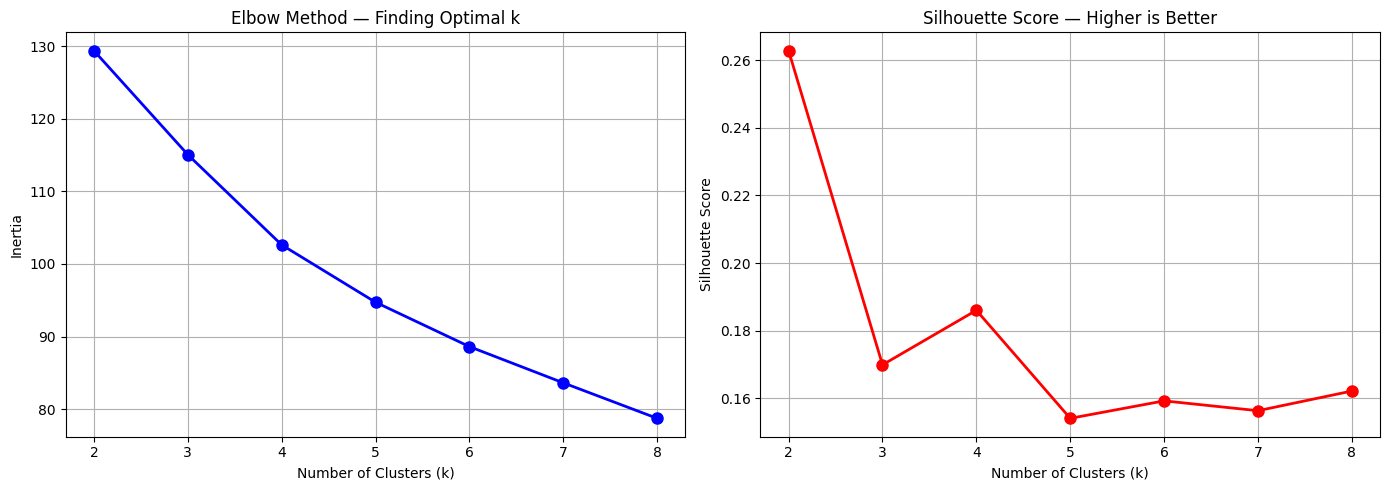

Best silhouette scores:
  k=2: 0.263
  k=3: 0.170
  k=4: 0.186
  k=5: 0.154
  k=6: 0.159
  k=7: 0.156
  k=8: 0.162


In [6]:
# find optimal number of clusters using Elbow Method
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled[all_indicators])
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_scaled[all_indicators], kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method — Finding Optimal k')
ax1.grid(True)

ax2.plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score — Higher is Better')
ax2.grid(True)

plt.tight_layout()
plt.savefig('../assets/charts/06_optimal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("Best silhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.3f}")

apply kmeans with k=4

In [7]:
# apply KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled[all_indicators])

# analyze each cluster's average health risk score
cluster_analysis = df.groupby('cluster')['health_risk_score'].agg(['mean', 'count'])
cluster_analysis = cluster_analysis.sort_values('mean', ascending=False)
print("Cluster Analysis:")
print(cluster_analysis)

# rename clusters based on risk level
# highest mean score = highest risk
cluster_order = cluster_analysis.index.tolist()
risk_labels = {
    cluster_order[0]: 'Critical Risk',
    cluster_order[1]: 'High Risk',
    cluster_order[2]: 'Moderate Risk',
    cluster_order[3]: 'Low Risk'
}

df['risk_category'] = df['cluster'].map(risk_labels)

# summary
print("\nDistricts per risk category:")
print(df['risk_category'].value_counts())

print("\nAverage stunting by risk category:")
print(df.groupby('risk_category')['stunting_pct'].mean().round(2).sort_values(ascending=False))

Cluster Analysis:
             mean  count
cluster                 
0        0.646411    240
1        0.545874    286
3        0.545442     38
2        0.436278    143

Districts per risk category:
risk_category
High Risk        286
Critical Risk    240
Low Risk         143
Moderate Risk     38
Name: count, dtype: int64

Average stunting by risk category:
risk_category
Low Risk         42.62
Moderate Risk    35.03
High Risk        33.89
Critical Risk    27.21
Name: stunting_pct, dtype: float64


reassign labels correctly

In [8]:
# fix cluster labels based on actual risk score ranking
cluster_means = df.groupby('cluster')['health_risk_score'].mean().sort_values(ascending=False)
print("Cluster means (sorted high to low risk):")
print(cluster_means)

# reassign correctly
risk_map = {}
labels = ['Critical Risk', 'High Risk', 'Moderate Risk', 'Low Risk']
for i, cluster_num in enumerate(cluster_means.index):
    risk_map[cluster_num] = labels[i]

df['risk_category'] = df['cluster'].map(risk_map)

print("\nCorrected districts per risk category:")
print(df['risk_category'].value_counts())

print("\nCorrected average stunting by risk category:")
print(df.groupby('risk_category')['stunting_pct'].mean().round(2).sort_values(ascending=False))

print("\nCorrected average health risk score by category:")
print(df.groupby('risk_category')['health_risk_score'].mean().round(3).sort_values(ascending=False))

Cluster means (sorted high to low risk):
cluster
0    0.646411
1    0.545874
3    0.545442
2    0.436278
Name: health_risk_score, dtype: float64

Corrected districts per risk category:
risk_category
High Risk        286
Critical Risk    240
Low Risk         143
Moderate Risk     38
Name: count, dtype: int64

Corrected average stunting by risk category:
risk_category
Low Risk         42.62
Moderate Risk    35.03
High Risk        33.89
Critical Risk    27.21
Name: stunting_pct, dtype: float64

Corrected average health risk score by category:
risk_category
Critical Risk    0.646
High Risk        0.546
Moderate Risk    0.545
Low Risk         0.436
Name: health_risk_score, dtype: float64


build the folium map

In [10]:
# build interactive India map
# center coordinates of India
india_map = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles='CartoDB positron'
)

# Color scheme for risk categories
color_map = {
    'Critical Risk': '#d73027',
    'High Risk': '#fc8d59',
    'Moderate Risk': '#fee090',
    'Low Risk': '#91cf60'
}

# District coordinates (approximate - using state centroids)
state_coords = {
    'Andhra Pradesh': [15.9129, 79.7400],
    'Arunachal Pradesh': [28.2180, 94.7278],
    'Assam': [26.2006, 92.9376],
    'Bihar': [25.0961, 85.3131],
    'Chhattisgarh': [21.2787, 81.8661],
    'Goa': [15.2993, 74.1240],
    'Gujarat': [22.2587, 71.1924],
    'Haryana': [29.0588, 76.0856],
    'Himachal Pradesh': [31.1048, 77.1734],
    'Jharkhand': [23.6102, 85.2799],
    'Karnataka': [15.3173, 75.7139],
    'Kerala': [10.8505, 76.2711],
    'Madhya Pradesh': [22.9734, 78.6569],
    'Maharashtra': [19.7515, 75.7139],
    'Manipur': [24.6637, 93.9063],
    'Meghalaya': [25.4670, 91.3662],
    'Mizoram': [23.1645, 92.9376],
    'Nagaland': [26.1584, 94.5624],
    'Odisha': [20.9517, 85.0985],
    'Punjab': [31.1471, 75.3412],
    'Rajasthan': [27.0238, 74.2179],
    'Sikkim': [27.5330, 88.5122],
    'Tamil Nadu': [11.1271, 78.6569],
    'Telangana': [18.1124, 79.0193],
    'Tripura': [23.9408, 91.9882],
    'Uttar Pradesh': [26.8467, 80.9462],
    'Uttarakhand': [30.0668, 79.0193],
    'West Bengal': [22.9868, 87.8550],
    'Andaman & Nicobar Islands': [11.7401, 92.6586],
    'Chandigarh': [30.7333, 76.7794],
    'Dadra and Nagar Haveli & Daman and Diu': [20.1809, 73.0169],
    'Delhi': [28.7041, 77.1025],
    'Jammu & Kashmir': [33.7782, 76.5762],
    'Ladakh': [34.1526, 77.5770],
    'Lakshadweep': [10.5667, 72.6417],
    'Puducherry': [11.9416, 79.8083]
}

# Add circle markers for each district
for idx, row in df.iterrows():
    state = row['state']
    if state not in state_coords:
        continue

    # Add small random offset so districts don't overlap
    lat = state_coords[state][0] + np.random.uniform(-1.5, 1.5)
    lon = state_coords[state][1] + np.random.uniform(-1.5, 1.5)

    color = color_map.get(row['risk_category'], 'gray')

    popup_text = f"""
    <b>{row['district']}</b><br>
    State: {state}<br>
    Risk Category: {row['risk_category']}<br>
    Health Risk Score: {row['health_risk_score']}<br>
    Stunting: {row['stunting_pct']}%<br>
    Child Anaemia: {row['child_anaemia_pct']}%<br>
    Sanitation: {row['sanitation_pct']}%<br>
    Women Literacy: {row['women_literacy_pct']}%
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(india_map)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
     background-color: white; padding: 15px; border-radius: 10px;
     border: 2px solid grey; font-size: 14px;">
<b>Health Risk Category</b><br>
<i style="background:#d73027;width:12px;height:12px;display:inline-block;border-radius:50%"></i> Critical Risk<br>
<i style="background:#fc8d59;width:12px;height:12px;display:inline-block;border-radius:50%"></i> High Risk<br>
<i style="background:#fee090;width:12px;height:12px;display:inline-block;border-radius:50%"></i> Moderate Risk<br>
<i style="background:#91cf60;width:12px;height:12px;display:inline-block;border-radius:50%"></i> Low Risk<br>
</div>
"""
india_map.get_root().html.add_child(folium.Element(legend_html))

print("Map built successfully!")
print(f"Total districts plotted: {len(df)}")
india_map

Map built successfully!
Total districts plotted: 707


In [11]:
# Save map as interactive HTML file
map_path = '../dashboard/india_health_map.html'
india_map.save(map_path)

print(f"Map saved to: {map_path}")
print("Open this file in your browser to see the interactive map!")

Map saved to: ../dashboard/india_health_map.html
Open this file in your browser to see the interactive map!


save final dataset with scores

In [12]:
# save final dataset with risk scores and clusters
final_path = '../data/processed/nfhs5_with_risk_scores.csv'
df.to_csv(final_path, index=False)

print("Final dataset saved!")
print(f"Columns added: health_risk_score, cluster, risk_category")
print(f"\nRisk category distribution:")
print(df['risk_category'].value_counts())
print(f"\nFile saved to: {final_path}")

Final dataset saved!
Columns added: health_risk_score, cluster, risk_category

Risk category distribution:
risk_category
High Risk        286
Critical Risk    240
Low Risk         143
Moderate Risk     38
Name: count, dtype: int64

File saved to: ../data/processed/nfhs5_with_risk_scores.csv
